# Citation Intent Classification with Feed-Forward Neural Networks

This notebook develops and compares two PyTorch models for classifying scientific citation intent into **BACKGROUND**, **METHODS**, and **RESULTS**.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/thedevastator/harvesting-scholarly-insight-with-scicite/validation.csv
/kaggle/input/datasets/thedevastator/harvesting-scholarly-insight-with-scicite/train.csv
/kaggle/input/datasets/thedevastator/harvesting-scholarly-insight-with-scicite/test.csv


In [2]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from nltk.tokenize import word_tokenize

---
## 1. Data Loading

Load the predefined training, validation, and test splits of the SciCite dataset.

In [3]:
df = pd.read_csv("/kaggle/input/datasets/thedevastator/harvesting-scholarly-insight-with-scicite/train.csv")
validation_df = pd.read_csv("/kaggle/input/datasets/thedevastator/harvesting-scholarly-insight-with-scicite/validation.csv")
test_df = pd.read_csv("/kaggle/input/datasets/thedevastator/harvesting-scholarly-insight-with-scicite/test.csv")


## 2. Exploratory Data Analysis

Inspect representative records, label balance, and missing values before preprocessing.

In [4]:
#General stats
df.head(3)

,string,sectionName,label,citingPaperId,citedPaperId,excerpt_index,isKeyCitation,label2,citeEnd,citeStart,source,label_confidence,label2_confidence,id
0,"However, how frataxin interacts with the Fe-S ...",Introduction,1,1872080baa7d30ec8fb87be9a65358cd3a7fb649,894be9b4ea46a5c422e81ef3c241072d4c73fdc0,11,True,3,175,168,4,1.0,0.0,1872080baa7d30ec8fb87be9a65358cd3a7fb649>894be...
1,"In the study by Hickey et al. (2012), spikes w...",Novel Quantitative Trait Loci for Seminal Root...,1,ce1d09a4a3a8d7fd3405b9328f65f00c952cf64b,b6642e19efb8db5623b3cc4eef1c5822a6151107,2,True,3,36,16,4,1.0,0.0,ce1d09a4a3a8d7fd3405b9328f65f00c952cf64b>b6642...
2,"The drug also reduces catecholamine secretion,...",Introduction,1,9cdf605beb1aa1078f235c4332b3024daa8b31dc,4e6a17fb8d7a3cada601d942e22eb5da6d01adbd,0,False,3,228,225,4,1.0,0.0,9cdf605beb1aa1078f235c4332b3024daa8b31dc>4e6a1...


Text(0.5, 1.0, 'Label distribution')

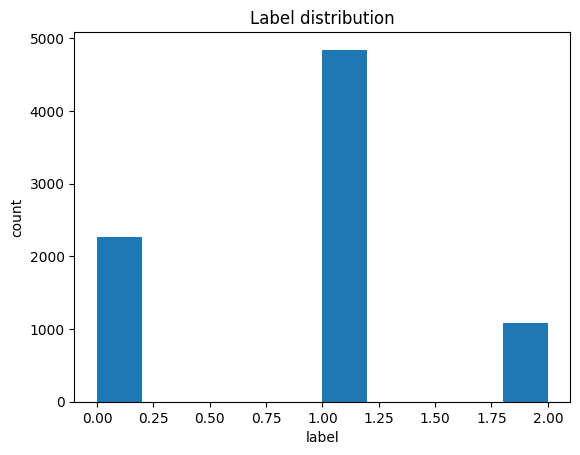

In [5]:
plt.hist(df["label"])
plt.xlabel("label")
plt.ylabel("count")
plt.title("Label distribution")

### 2.1 Class Distribution and Loss Weights

In [6]:
#weights for balanced Cross Entropy
weights = len(df["label"]) / (df["label"].value_counts() * 3)
print(weights)

label
1    0.564325
0    1.205355
2    2.510417
Name: count, dtype: float64


In [7]:
df.isnull().sum()

string                 0
sectionName          606
label                  0
citingPaperId          0
citedPaperId         106
excerpt_index          0
isKeyCitation          0
label2                 0
citeEnd                0
citeStart              0
source                 0
label_confidence       0
label2_confidence      0
id                     0
dtype: int64

---
## 3. Text Preprocessing

Normalize missing section names, replace the target citation with `<cite>`, and tokenize scientific text while preserving domain-specific special tokens.

In [8]:
df["sectionName"] = df["sectionName"].fillna("<unknown_section>")
validation_df["sectionName"] = validation_df["sectionName"].fillna("<unknown_section>")
test_df["sectionName"] = test_df["sectionName"].fillna("<unknown_section>")

In [9]:
df.loc[0]["string"][df.loc[0]["citeStart"]:df.loc[0]["citeEnd"]]
for i in range(10,15):
    print(f"SENTENCE: {df.loc[i]["string"]}, \nCITATION: {df.loc[i]["string"][df.loc[i]["citeStart"]:df.loc[i]["citeEnd"]]},\n SECTION NAME: {df.loc[i]["sectionName"]}")
    print("-----------------")

SENTENCE: …lifetimes, whereas indirect benefits refer to benefits to genetically related recipients; i.e., benefits that increase the inclusive fitness of benefactors but typicaly imply fitness costs that are not compensated during the benefactors’ lifetimes (Hamilton 1964; Trivers 1971; West et al. 2007)., 
CITATION:  Trivers 197,
 SECTION NAME: Implications for Explaining Cooperation: Towards a Classification in Terms of Psychological Mechanisms
-----------------
SENTENCE: DOI: 10.7554/eLife.08828 1 of 27
mitochondrial division (Friedman et al., 2011; Korobova et al., 2013; Murley et al., 2013; Korobova et al., 2014)., 
CITATION: Korobova et al., 2013,
 SECTION NAME: Introduction
-----------------
SENTENCE: The remnant of the total plasma membranes after extraction of caveolae is called bulk plasma membranes (40) (Fig., 
CITATION: (40),
 SECTION NAME: RESULTS
-----------------
SENTENCE: We used an active contour algorithm [10] to segment the organs from 340 coronal slices over the tw

In [10]:
#ADDING <cite> token for determined position of citation

def tokenization_of_cite(data):
    data["string"] = data.apply(
    lambda row: (
        row["string"][:row["citeStart"]]
        + " <cite> "
        + row["string"][row["citeEnd"]:]
    ),
    axis=1,
    )
    return data

df = tokenization_of_cite(df)
validation_df = tokenization_of_cite(validation_df)
test_df = tokenization_of_cite(test_df)

In [11]:
import re
import html
import unicodedata
from nltk.tokenize import word_tokenize


#Patterns for target tokenization

DOI_PATTERN = re.compile(
    r"""
    (?:
        https?://(?:dx\.)?doi\.org/
    )?
    \b10\.\d{4,9}/[-._;()/:a-zA-Z0-9]+
    """,
    flags=re.VERBOSE | re.IGNORECASE,
)

URL_PATTERN = re.compile(
    r"""
    (?:
        https?://
        |
        www\.
        |
        //
    )
    [^\s<>()]+
    """,
    flags=re.VERBOSE | re.IGNORECASE,
)

EMAIL_PATTERN = re.compile(
    r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b"
)

PHONE_PATTERN = re.compile(
    r"""
    (?<!\w)
    (?:\+\d{1,3}[-.\s]?)?
    (?:\(?\d{2,4}\)?[-.\s]?){2,}
    \d{2,4}
    (?!\w)
    """,
    flags=re.VERBOSE,
)

NUMBER_PATTERN = re.compile(
    r"""
    ^[+-]?
    (?:
        \d+(?:[.,]\d+)?
        |
        [.,]\d+
    )
    (?:[eE][+-]?\d+)?
    $
    """,
    flags=re.VERBOSE,
)

NUMBER_RANGE_PATTERN = re.compile(
    r"""
    ^[+-]?\d+(?:[.,]\d+)?
    [-–—]
    [+-]?\d+(?:[.,]\d+)?$
    """,
    flags=re.VERBOSE,
)


#PROTECTED TOKENS
SPECIAL_TOKEN_TO_PLACEHOLDER = {
    "<cite>": "zzzcitetokenzzz",
    "<url>": "zzzurltokenzzz",
    "<doi>": "zzzdoitokenzzz",
    "<email>": "zzzemailtokenzzz",
    "<phone>": "zzwebphonetokenzzz",
    "<unknown_section>": "zzzunknownsectiontokenzzz"
}

PLACEHOLDER_TO_SPECIAL_TOKEN = {
    placeholder: special_token
    for special_token, placeholder
    in SPECIAL_TOKEN_TO_PLACEHOLDER.items()
}


#SYMBOLS WHICH WE KEEP
KEPT_SYMBOLS = {
    "%",
    "<",
    ">",
    "=",
    "≤",
    "≥",
    "±",
}

MOJIBAKE_CHARACTERS = {
    "�",
    "Ã",
    "Â",
    "â",
}


def normalize_unicode(text):
    """Normalize Unicode, HTML entities and control characters."""

    text = html.unescape(str(text))
    text = unicodedata.normalize("NFKC", text)

    cleaned_characters = []

    for character in text:
        category = unicodedata.category(character)

        if category in {"Cc", "Cf"}:
            cleaned_characters.append(" ")
        else:
            cleaned_characters.append(character)

    text = "".join(cleaned_characters)
    text = re.sub(r"\s+", " ", text)

    return text.strip()


def replace_structured_patterns(text):
    """Replace URLs, DOIs, emails and phone numbers."""

    text = DOI_PATTERN.sub(" <doi> ", text)
    text = EMAIL_PATTERN.sub(" <email> ", text)
    text = URL_PATTERN.sub(" <url> ", text)
    text = PHONE_PATTERN.sub(" <phone> ", text)

    return text


def protect_special_tokens(text):
    """Protect special tokens from being split by word_tokenize."""

    for special_token, placeholder in SPECIAL_TOKEN_TO_PLACEHOLDER.items():
        text = text.replace(special_token, placeholder)

    return text


def is_only_punctuation_or_symbols(token):
    """Check whether token contains only punctuation or symbols."""

    if not token:
        return True

    return all(
        unicodedata.category(character)[0] in {"P", "S"}
        for character in token
    )


def normalize_token(token):
    """Normalize or remove one token."""

    token = token.strip()

    # Remove artificial quote markers produced by tokenizers
    token = token.strip('"`')

    if not token:
        return None

    # Restore protected special tokens
    if token in PLACEHOLDER_TO_SPECIAL_TOKEN:
        return PLACEHOLDER_TO_SPECIAL_TOKEN[token]

    # Remove visibly corrupted encoding fragments
    if any(character in token for character in MOJIBAKE_CHARACTERS):
        return None

    # Normalize numbers and numeric ranges
    if NUMBER_PATTERN.fullmatch(token):
        return "<num>"

    if NUMBER_RANGE_PATTERN.fullmatch(token):
        return "<num>"

    # Keep selected scientifically useful symbols
    if token in KEPT_SYMBOLS:
        return token

    # Remove tokens consisting only of punctuation/symbols
    if is_only_punctuation_or_symbols(token):
        return None

    return token


def clean_and_tokenize(text):
    """Complete preprocessing pipeline for one citation context."""

    text = normalize_unicode(text)
    text = text.lower()
    text = replace_structured_patterns(text)
    text = protect_special_tokens(text)

    raw_tokens = word_tokenize(text)

    normalized_tokens = []

    for token in raw_tokens:
        normalized_token = normalize_token(token)

        if normalized_token is not None:
            normalized_tokens.append(normalized_token)

    return normalized_tokens


def preprocess_text(data, save_column = "tokenized_string", source_column="string"):
    """Apply preprocessing to a complete DataFrame."""

    data = data.copy()

    data[save_column] = data[source_column].apply(
        clean_and_tokenize
    )

    return data

In [12]:
df = preprocess_text(df)
validation_df = preprocess_text(validation_df)
test_df = preprocess_text(test_df)

df = preprocess_text(
    df,
    save_column="tokenized_section",
    source_column="sectionName"
)

validation_df = preprocess_text(
    validation_df,
    save_column="tokenized_section",
    source_column="sectionName"
)

test_df = preprocess_text(
    test_df,
    save_column="tokenized_section",
    source_column="sectionName"
)

---
## 4. Vocabulary Construction

Build a shared training vocabulary for citation contexts and section titles, then replace rare or unseen tokens with `<unk>`.

In [13]:
vocabulary = {
    token
    for column in ["tokenized_string", "tokenized_section"]
    for sentence in df[column]
    for token in sentence
}
vocabulary.add("<unk>")
vocabulary.add("<pad>")
vocabulary.add("<unknown_section>")

percentile_95 = df["tokenized_string"].str.len().quantile(0.964)
print(percentile_95)
print(f"Size of vocabulary : {len(vocabulary)}")

54.0
Size of vocabulary : 29844


In [14]:
from collections import Counter

word_counts = Counter(
    token
    for column in ["tokenized_string", "tokenized_section"]
    for sentence in df[column]
    for token in sentence
)

In [15]:
for threshold in [1, 2, 3, 5, 10]:
    count = sum(
        frequency <= threshold
        for frequency in word_counts.values()
    )
    print(f"Frequency <= {threshold}: {count}")

Frequency <= 1: 16398
Frequency <= 2: 21252
Frequency <= 3: 23302
Frequency <= 5: 25344
Frequency <= 10: 27294


In [16]:
filtered_vocabulary = vocabulary.copy()
for word in vocabulary:
    if word_counts[word] <=1 and word not in [
    "<cite>",
    "<url>",
    "<doi>",
    "<email>",
    "<phone>",
    "<num>",
    "<unk>",
    "<pad>",
    "<unknown_section>",
]:
        filtered_vocabulary.remove(word)

In [17]:
print(f"Size of filtered vocabulary: {len(filtered_vocabulary)}")
word2idx = {word : i for i, word in enumerate(vocabulary)}

Size of filtered vocabulary: 13446


In [18]:
def replace_rare_tokens(data):
    for column in ["tokenized_string", "tokenized_section"]:
        data[column] = data[column].apply(
            lambda words: [
                word if word in filtered_vocabulary and word != "<unk>" else "<unk>" for word in words
            ]
        )
    return data


df = replace_rare_tokens(df)
validation_df = replace_rare_tokens(validation_df)
test_df = replace_rare_tokens(test_df)

---
## 5. Baseline Model

The baseline uses the complete citation context only: shared token embeddings are aggregated with masked mean pooling and passed to a feed-forward classifier.

### 5.1 Hyperparameters

In [19]:
min_frequency = 2
max_length = 54
batch_size = 32
embed_size = 100

pad_idx = word2idx["<pad>"]

model_hyperparameters = {
    "batch_size": batch_size,
    "embed_dim": embed_size,
    "hidden_dim": 128,
    "freeze_embeddings": False,
    "num_classes": 3,
    "dropout_rate": 0.3
}

### 5.2 Data Pipeline

In [20]:
from torch.utils.data import Dataset, DataLoader 
from torch.nn.utils.rnn import pad_sequence
import torch.optim as optim
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

def tokens_to_idx(sentence, word_to_idx=word2idx):
    unk_idx = word_to_idx["<unk>"]
    return [word_to_idx.get(word, unk_idx) for word in sentence]


class CitationDataset(Dataset):
    def __init__(self, data, x_var = "tokenized_string", y_var = "label"):
        self.data = data
        self.x_var = x_var
        self.y_var = y_var

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
    
        sentence = torch.as_tensor(
            tokens_to_idx(row[self.x_var]),
            dtype=torch.long
        )
    
        label = torch.as_tensor(
            row[self.y_var],
            dtype=torch.long
        ).squeeze()
        return sentence, label

def collate_fn(batch, max_length=max_length, pad_idx=pad_idx):
    x, y = zip(*batch)
    x = [sentence[:max_length] for sentence in x]
    x_padded = pad_sequence(
        x,
        batch_first=True,
        padding_value=pad_idx,
    )
    y_padded = torch.stack(y)
    mask = x_padded != pad_idx
    return x_padded, y_padded, mask


def create_dataloader(data, shuffle=False):
    return DataLoader(
        CitationDataset(data),
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=collate_fn,
    )


loader = create_dataloader(df, shuffle=True)
validation_loader = create_dataloader(validation_df)
test_loader = create_dataloader(test_df)

### 5.3 Model Architecture

In [21]:
class AbstractSentenceClassifier(nn.Module):

  def __init__(self, hyperparameters, vocab_size = len(vocabulary), pad_ix=pad_idx):
    super(AbstractSentenceClassifier, self).__init__()

    self.embed_dim = hyperparameters["embed_dim"]
    self.hidden_dim = hyperparameters["hidden_dim"]
    self.freeze_embeddings = hyperparameters["freeze_embeddings"]
    self.num_classes = hyperparameters["num_classes"]
    self.dropout_rate = hyperparameters["dropout_rate"]

    self.embed_layer = nn.Embedding(vocab_size, self.embed_dim, padding_idx=pad_ix)
    if self.freeze_embeddings:
      self.embed_layer.weight.requires_grad = False

    self.hidden_layer = nn.Sequential(
      nn.Linear(self.embed_dim, self.hidden_dim),
      nn.Tanh(),
      nn.Dropout(self.dropout_rate)
    )
    
    self.logits = nn.Linear(self.hidden_dim, self.num_classes)

  def forward(self, inputs, mask):
    embedded_input = self.embed_layer(inputs)
    masked_embeds = (embedded_input * mask.unsqueeze(-1)).sum(dim=1)
    
    lengths = (
        mask.sum(dim=1, keepdim=True)
        .clamp(min=1)
    )
      
    #mean pooling with mask applying approach
    sentence_vector = masked_embeds / lengths
    
    output = self.logits(self.hidden_layer(sentence_vector))
    
    return output

### 5.4 Optimization Setup

In [22]:
learning_rate = 5e-4
weight_decay = 1e-5

model = AbstractSentenceClassifier(model_hyperparameters)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

#for class balancing
class_weights = torch.tensor([weights[0], weights[1], weights[2]], dtype=torch.float, device=device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
model = model.to(device)

### 5.5 Training and Evaluation Utilities

In [23]:
def train_epoch(criterion, optimizer, model, loader, device):
    
  model.train()
  total_loss = 0
    
  for batch_inputs, batch_labels, batch_masks in loader:

    
      
    batch_inputs = batch_inputs.to(device)
    batch_labels = batch_labels.to(device)
    batch_masks = batch_masks.to(device)
    
    optimizer.zero_grad()
    outputs = model(batch_inputs, batch_masks)
    
    loss = criterion(outputs, batch_labels)
    
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
      
  return total_loss / len(loader)

def evaluate(criterion, model, loader, device):
    model.eval()

    total_loss = 0.0
    total_examples = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for batch_inputs, batch_labels, batch_masks in loader:
            batch_inputs = batch_inputs.to(device)
            batch_labels = batch_labels.to(device)
            batch_masks = batch_masks.to(device)

            logits = model(batch_inputs, batch_masks)
            loss = criterion(logits, batch_labels)

            batch_size = batch_labels.size(0)

            total_loss += loss.item() * batch_size
            total_examples += batch_size

            predictions = logits.argmax(dim=1)

            all_labels.extend(batch_labels.cpu().tolist())
            all_predictions.extend(predictions.cpu().tolist())

    average_loss = total_loss / total_examples

    metrics = {
        "loss": average_loss,
        "accuracy": accuracy_score(all_labels, all_predictions),
        "macro_f1": f1_score(
            all_labels,
            all_predictions,
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            all_labels,
            all_predictions,
            average="weighted",
            zero_division=0,
        ),
    }

    return metrics, all_labels, all_predictions

def train(
    criterion,
    optimizer,
    model,
    train_loader,
    validation_loader,
    device,
    num_epochs,
):
    best_macro_f1 = 0.0

    for epoch in range(num_epochs):
        train_loss = train_epoch(
            criterion,
            optimizer,
            model,
            train_loader,
            device,
        )

        val_metrics, val_labels, val_predictions = evaluate(
            criterion,
            model,
            validation_loader,
            device,
        )

        print(
            f"Epoch {epoch + 1:03d} | "
            f"train loss: {train_loss:.4f} | "
            f"val loss: {val_metrics['loss']:.4f} | "
            f"accuracy: {val_metrics['accuracy']:.4f} | "
            f"macro-F1: {val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["macro_f1"] > best_macro_f1:
            best_macro_f1 = val_metrics["macro_f1"]

            torch.save(
                model.state_dict(),
                "best_model.pt",
            )

### 5.6 Training Run

In [24]:
num_epochs = 12

train(
    criterion,
    optimizer,
    model,
    loader,
    validation_loader,
    device,
    num_epochs,
)

Epoch 001 | train loss: 0.9805 | val loss: 0.8549 | accuracy: 0.5950 | macro-F1: 0.5879
Epoch 002 | train loss: 0.7374 | val loss: 0.7013 | accuracy: 0.6769 | macro-F1: 0.6572
Epoch 003 | train loss: 0.6008 | val loss: 0.6473 | accuracy: 0.7009 | macro-F1: 0.6817
Epoch 004 | train loss: 0.5170 | val loss: 0.6317 | accuracy: 0.7369 | macro-F1: 0.7141
Epoch 005 | train loss: 0.4606 | val loss: 0.6273 | accuracy: 0.7456 | macro-F1: 0.7264
Epoch 006 | train loss: 0.4094 | val loss: 0.6270 | accuracy: 0.7467 | macro-F1: 0.7248
Epoch 007 | train loss: 0.3639 | val loss: 0.6380 | accuracy: 0.7533 | macro-F1: 0.7295
Epoch 008 | train loss: 0.3217 | val loss: 0.6438 | accuracy: 0.7456 | macro-F1: 0.7250
Epoch 009 | train loss: 0.2841 | val loss: 0.6648 | accuracy: 0.7467 | macro-F1: 0.7278
Epoch 010 | train loss: 0.2545 | val loss: 0.6918 | accuracy: 0.7467 | macro-F1: 0.7301
Epoch 011 | train loss: 0.2255 | val loss: 0.7177 | accuracy: 0.7598 | macro-F1: 0.7394
Epoch 012 | train loss: 0.1976 |

### 5.7 Validation Results

Restore the checkpoint with the highest validation macro-F1 and inspect class-level performance.

In [25]:
model.load_state_dict(
    torch.load("best_model.pt", map_location=device)
)

val_metrics, val_labels, val_predictions = evaluate(
    criterion,
    model,
    validation_loader,
    device,
)

In [26]:
label_names = [
    "BACKGROUND",
    "METHODS",
    "RESULTS",
]

In [27]:
print(
    classification_report(
        val_labels,
        val_predictions,
        target_names=label_names,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

  BACKGROUND       0.66      0.77      0.71       255
     METHODS       0.86      0.75      0.80       538
     RESULTS       0.65      0.77      0.71       123

    accuracy                           0.76       916
   macro avg       0.72      0.77      0.74       916
weighted avg       0.77      0.76      0.76       916



### 5.8 Test Results

In [28]:
test_metrics, test_labels, test_predictions = evaluate(
    criterion,
    model,
    test_loader,
    device,
)

test_metrics

{'loss': 0.6059475004324322,
 'accuracy': 0.7735341581495427,
 'macro_f1': 0.7566749226754227,
 'weighted_f1': 0.7761038536436344}

---
## 6. Advanced Multi-Input Model

The advanced model combines the full context, section title, local left/right citation context, and normalized citation position before classification.

### 6.1 Advanced Data Pipeline

In [29]:
class CitationDatasetAdvanced(Dataset):
    def __init__(self, data, x_var = "tokenized_string", y_var = "label"):
        self.data = data
        self.x_var = x_var
        self.y_var = y_var

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        tokens = row[self.x_var]
        cite_idx = tokens.index("<cite>")
        
        sentence = torch.as_tensor(
            tokens_to_idx(tokens),
            dtype=torch.long
        )

        section = torch.as_tensor(
            tokens_to_idx(row["tokenized_section"]),
            dtype=torch.long
        )

        left_context = torch.as_tensor(
            tokens_to_idx(tokens[:cite_idx]),
            dtype=torch.long
        )
        
        right_context = torch.as_tensor(
            tokens_to_idx(tokens[cite_idx + 1:]),
            dtype=torch.long
        )

        position = torch.as_tensor(
            row["citeStart"] / len(row["string"]),dtype=torch.float32
        ).squeeze()
        
        label = torch.as_tensor(
            row[self.y_var],
            dtype=torch.long
        ).squeeze()

        
        return sentence, section, left_context, right_context, position, label

def collate_fn_advanced(batch, max_length=max_length, context_window=15, pad_idx=pad_idx):
    sentences, sections, left_contexts, right_contexts, positions, labels = zip(*batch)

    #Full sentences
    sentences = [
        sentence[:max_length]
        for sentence in sentences
    ]

    sections = [
        section[:max_length]
        for section in sections
    ]

    #Tokens closest to <cite>
    left_contexts = [
        context[-context_window:]
        for context in left_contexts
    ]

    right_contexts = [
        context[:context_window]
        for context in right_contexts
    ]

    #Protect pad_sequence from completely empty sequences
    empty_sequence = lambda: torch.tensor([pad_idx], dtype=torch.long)

    sections = [
        section if len(section) > 0 else empty_sequence()
        for section in sections
    ]

    left_contexts = [
        context if len(context) > 0 else empty_sequence()
        for context in left_contexts
    ]

    right_contexts = [
        context if len(context) > 0 else empty_sequence()
        for context in right_contexts
    ]

    sentences_padded = pad_sequence(
        sentences,
        batch_first=True,
        padding_value=pad_idx
    )

    sections_padded = pad_sequence(
        sections,
        batch_first=True,
        padding_value=pad_idx
    )

    left_contexts_padded = pad_sequence(
        left_contexts,
        batch_first=True,
        padding_value=pad_idx
    )

    right_contexts_padded = pad_sequence(
        right_contexts,
        batch_first=True,
        padding_value=pad_idx
    )

    sentence_mask = sentences_padded != pad_idx
    section_mask = sections_padded != pad_idx
    left_context_mask = left_contexts_padded != pad_idx
    right_context_mask = right_contexts_padded != pad_idx

    positions = torch.stack(positions).unsqueeze(-1)  # [B, 1]
    labels = torch.stack(labels)                       # [B]

    return (
        sentences_padded,
        sections_padded,
        left_contexts_padded,
        right_contexts_padded,
        positions,
        labels,
        sentence_mask,
        section_mask,
        left_context_mask,
        right_context_mask
    )


def create_dataloader_advanced(data, shuffle=False):
    return DataLoader(
        CitationDatasetAdvanced(data),
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=collate_fn_advanced,
    )

loader_advance = create_dataloader_advanced(df, shuffle=True)
validation_loader_advance = create_dataloader_advanced(validation_df)
test_loader_advance = create_dataloader_advanced(test_df)

### 6.2 Multi-Input Architecture

In [30]:
class ImprovedModel(nn.Module):
    def __init__(self, hyperparameters, vocab_size=len(vocabulary), pad_ix=pad_idx):
        super().__init__()
        self.embed_dim = hyperparameters["embed_dim"]
        self.hidden_dim = hyperparameters["hidden_dim"]
        self.freeze_embeddings = hyperparameters["freeze_embeddings"]
        self.num_classes = hyperparameters["num_classes"]
        self.dropout_rate = hyperparameters["dropout_rate"]

        self.embed_layer = nn.Embedding(vocab_size, self.embed_dim, padding_idx=pad_ix)

        if self.freeze_embeddings:
            self.embed_layer.weight.requires_grad = False

        combined_dim = self.embed_dim * 4 + 1

        self.hidden_layer = nn.Sequential(
            nn.Linear(combined_dim, self.hidden_dim),
            nn.Tanh(),
            nn.Dropout(self.dropout_rate)
        )

        self.logits = nn.Linear(
            self.hidden_dim,
            self.num_classes
        )

    def masked_mean_pooling(self, inputs, mask):
        embedded_inputs = self.embed_layer(inputs)

        masked_embeds = (
            embedded_inputs * mask.unsqueeze(-1)
        ).sum(dim=1)

        lengths = (
            mask.sum(dim=1, keepdim=True)
            .clamp(min=1)
        )

        return masked_embeds / lengths

    def forward(
        self,
        sentences,
        sections,
        left_contexts,
        right_contexts,
        positions,
        sentence_mask,
        section_mask,
        left_context_mask,
        right_context_mask
        ):
        
        sentence_vector = self.masked_mean_pooling(sentences, sentence_mask)
        section_vector = self.masked_mean_pooling(sections, section_mask)

        left_context_vector = self.masked_mean_pooling(left_contexts, left_context_mask)
        right_context_vector = self.masked_mean_pooling(right_contexts, right_context_mask)

        combined_vector = torch.cat(
            [
                sentence_vector,
                section_vector,
                left_context_vector,
                right_context_vector,
                positions
            ],
            dim=1
        )

        output = self.logits(
                self.hidden_layer(combined_vector)
            )

        return output

### 6.3 Batch Preparation

In [31]:
def prepare_advanced_batch(batch, device):
    (
        batch_sentences,
        batch_sections,
        batch_left_contexts,
        batch_right_contexts,
        batch_positions,
        batch_labels,
        batch_sentence_mask,
        batch_section_mask,
        batch_left_context_mask,
        batch_right_context_mask
    ) = batch

    model_inputs = (
        batch_sentences.to(device),
        batch_sections.to(device),
        batch_left_contexts.to(device),
        batch_right_contexts.to(device),
        batch_positions.to(device),
        batch_sentence_mask.to(device),
        batch_section_mask.to(device),
        batch_left_context_mask.to(device),
        batch_right_context_mask.to(device)
    )

    batch_labels = batch_labels.to(device)

    return model_inputs, batch_labels

### 6.4 Training and Evaluation Utilities

In [32]:
def train_epoch_advanced(criterion, optimizer, model, loader, device):
    
  model.train()
  total_loss = 0
    
  for batch in loader:
    model_inputs, batch_labels = prepare_advanced_batch(
        batch,
        device
    )

    optimizer.zero_grad()

    outputs = model(*model_inputs)
    loss = criterion(outputs, batch_labels)

    loss.backward()
    optimizer.step()

    total_loss += loss.item()
      
  return total_loss / len(loader)

def evaluate_advanced(criterion, model, loader, device):
    model.eval()

    total_loss = 0.0
    total_examples = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for batch in loader:
            model_inputs, batch_labels = prepare_advanced_batch(
                batch,
                device
            )
    
            logits = model(*model_inputs)
            loss = criterion(logits, batch_labels)
    
            batch_size = batch_labels.size(0)
    
            total_loss += loss.item() * batch_size
            total_examples += batch_size
    
            predictions = logits.argmax(dim=1)
    
            all_labels.extend(batch_labels.cpu().tolist())
            all_predictions.extend(predictions.cpu().tolist())

    average_loss = total_loss / total_examples

    metrics = {
        "loss": average_loss,
        "accuracy": accuracy_score(all_labels, all_predictions),
        "macro_f1": f1_score(
            all_labels,
            all_predictions,
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            all_labels,
            all_predictions,
            average="weighted",
            zero_division=0,
        ),
    }

    return metrics, all_labels, all_predictions

def train_advanced(
    criterion,
    optimizer,
    model,
    train_loader,
    validation_loader,
    device,
    num_epochs,
):
    best_macro_f1 = 0.0

    for epoch in range(num_epochs):
        train_loss = train_epoch_advanced(
            criterion,
            optimizer,
            model,
            train_loader,
            device,
        )

        val_metrics, val_labels, val_predictions = evaluate_advanced(
            criterion,
            model,
            validation_loader,
            device,
        )

        print(
            f"Epoch {epoch + 1:03d} | "
            f"train loss: {train_loss:.4f} | "
            f"val loss: {val_metrics['loss']:.4f} | "
            f"accuracy: {val_metrics['accuracy']:.4f} | "
            f"macro-F1: {val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["macro_f1"] > best_macro_f1:
            best_macro_f1 = val_metrics["macro_f1"]

            torch.save(
                model.state_dict(),
                "best_model.pt",
            )

### 6.5 Hyperparameters

In [33]:
min_frequency = 2
max_length = 54
batch_size = 32
embed_size = 1024

learning_rate = 5e-4
weight_decay = 1e-5

new_model_hyperparams = {
    "batch_size": batch_size,
    "embed_dim": embed_size,
    "hidden_dim": 2048,
    "freeze_embeddings": False,
    "num_classes": 3,
    "dropout_rate": 0.5
}

### 6.6 Optimization Setup

In [34]:
new_model = ImprovedModel(new_model_hyperparams)
optimizer = optim.AdamW(new_model.parameters(), lr=learning_rate, weight_decay=weight_decay)

#for class balancing
class_weights = torch.tensor([weights[0], weights[1], weights[2]], dtype=torch.float, device=device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
new_model = new_model.to(device)

### 6.7 Training Run

In [35]:
num_epochs=15
train_advanced(
    criterion,
    optimizer,
    new_model,
    loader_advance,
    validation_loader_advance,
    device,
    num_epochs,
)

Epoch 001 | train loss: 0.6993 | val loss: 0.5981 | accuracy: 0.7598 | macro-F1: 0.7286
Epoch 002 | train loss: 0.4960 | val loss: 0.5925 | accuracy: 0.7445 | macro-F1: 0.7248
Epoch 003 | train loss: 0.4153 | val loss: 0.6969 | accuracy: 0.7795 | macro-F1: 0.7551
Epoch 004 | train loss: 0.3235 | val loss: 0.6467 | accuracy: 0.7653 | macro-F1: 0.7405
Epoch 005 | train loss: 0.2642 | val loss: 0.6806 | accuracy: 0.8100 | macro-F1: 0.7857
Epoch 006 | train loss: 0.2100 | val loss: 0.6958 | accuracy: 0.7860 | macro-F1: 0.7589
Epoch 007 | train loss: 0.1683 | val loss: 0.8623 | accuracy: 0.7959 | macro-F1: 0.7658
Epoch 008 | train loss: 0.1375 | val loss: 0.9024 | accuracy: 0.8057 | macro-F1: 0.7721
Epoch 009 | train loss: 0.1235 | val loss: 0.9157 | accuracy: 0.8068 | macro-F1: 0.7769
Epoch 010 | train loss: 0.0896 | val loss: 0.9039 | accuracy: 0.8002 | macro-F1: 0.7761
Epoch 011 | train loss: 0.0741 | val loss: 0.9885 | accuracy: 0.8024 | macro-F1: 0.7734
Epoch 012 | train loss: 0.0712 |

### 6.8 Validation and Test Results

Restore the best advanced-model checkpoint and evaluate it on both held-out splits.

In [36]:
new_model.load_state_dict(
    torch.load("best_model.pt", map_location=device)
)

val_metrics, val_labels, val_predictions = evaluate_advanced(
    criterion,
    new_model,
    validation_loader_advance,
    device,
)

In [37]:
label_names = [
    "BACKGROUND",
    "METHODS",
    "RESULTS",
]

print(
    classification_report(
        val_labels,
        val_predictions,
        target_names=label_names,
        zero_division=0,
    )
)


test_metrics, test_labels, test_predictions = evaluate_advanced(
    criterion,
    new_model,
    test_loader_advance,
    device,
)

test_metrics

              precision    recall  f1-score   support

  BACKGROUND       0.78      0.78      0.78       255
     METHODS       0.84      0.87      0.86       538
     RESULTS       0.77      0.68      0.72       123

    accuracy                           0.82       916
   macro avg       0.80      0.78      0.79       916
weighted avg       0.82      0.82      0.82       916



{'loss': 1.0315445190222434,
 'accuracy': 0.8025820333512641,
 'macro_f1': 0.7697730649838427,
 'weighted_f1': 0.8060622988359619}

---
## 7. Results and Conclusion

| Model | Test loss | Test accuracy | Test macro-F1 | Test weighted-F1 |
|---|---:|---:|---:|---:|
| Baseline | 0.6059 | 0.7735 | 0.7567 | 0.7761 |
| Advanced | 1.0315 | **0.8026** | **0.7698** | **0.8061** |

The advanced multi-input model improved test accuracy by **2.90 percentage points**, macro-F1 by **1.31 points**, and weighted-F1 by **3.00 points**. This suggests that section information, citation-local context, and citation position provide useful signals beyond the complete sentence alone. However, its higher test loss and widening train–validation gap indicate stronger overconfidence and overfitting. Moreover, the advanced model has much greater capacity, so a controlled same-size ablation is required before attributing the gain solely to the additional inputs.